In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
links = pd.read_csv('links.csv')
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [3]:
movies = pd.read_csv('movies.csv')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings = pd.read_csv('ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
tags = pd.read_csv('tags.csv')
tags.head(20)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
5,2,89774,Tom Hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,Leonardo DiCaprio,1445715051
8,2,106782,Martin Scorsese,1445715056
9,7,48516,way too long,1169687325


In [6]:
tags['tag'].is_unique

False

In [7]:
merged_df = pd.merge(links, movies, on='movieId', how='left')
merged_df.head(5)


,movieId,imdbId,tmdbId,title,genres
0,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,113497,8844.0,Jumanji (1995),Adventure|Children|Fantasy
2,3,113228,15602.0,Grumpier Old Men (1995),Comedy|Romance
3,4,114885,31357.0,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,113041,11862.0,Father of the Bride Part II (1995),Comedy


In [8]:
merged_df_m = pd.merge(merged_df, ratings, on='movieId', how='left')
merged_df_m.head(10)


,movieId,imdbId,tmdbId,title,genres,userId,rating,timestamp
0,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,9.649827e+08
1,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,8.474350e+08
2,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7.0,4.5,1.106636e+09
3,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15.0,2.5,1.510578e+09
4,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17.0,4.5,1.305696e+09
5,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,18.0,3.5,1.455210e+09
6,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,19.0,4.0,9.657056e+08
7,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,21.0,3.5,1.407619e+09
8,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,27.0,3.0,9.626853e+08
9,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,31.0,5.0,8.504666e+08


In [9]:
merged_df_m.shape

(100854, 8)

In [10]:
merged_df_all = pd.merge(merged_df_m, tags, on=['movieId','userId'], how='left')
merged_df_all.head()


,movieId,imdbId,tmdbId,title,genres,userId,rating,timestamp_x,tag,timestamp_y
0,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,9.649827e+08,NaN,NaN
1,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,8.474350e+08,NaN,NaN
2,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7.0,4.5,1.106636e+09,NaN,NaN
3,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15.0,2.5,1.510578e+09,NaN,NaN
4,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17.0,4.5,1.305696e+09,NaN,NaN


In [11]:
user_rating_counts = merged_df_all['userId'].value_counts()
top_20_users = user_rating_counts.head(20)
top_20_users.head(20)

userId
599.0    2796
414.0    2698
474.0    2373
448.0    1864
274.0    1346
610.0    1303
68.0     1260
380.0    1218
606.0    1115
288.0    1055
249.0    1046
387.0    1027
182.0     977
307.0     975
603.0     943
298.0     939
177.0     906
318.0     902
232.0     862
480.0     836
Name: count, dtype: int64

In [12]:
user_tag_counts = merged_df_all.groupby('userId')['tag'].count()
user_tag_counts_sorted = user_tag_counts.sort_values(ascending=False)
top_20_users_tags = user_tag_counts_sorted.head(20)
top_20_users_tags.head(20)

userId
474.0    1414
567.0     432
62.0      370
599.0     323
477.0     267
424.0     223
537.0      90
125.0      48
357.0      45
318.0      36
184.0      35
193.0      17
18.0       16
573.0      12
119.0      12
336.0       9
2.0         9
305.0       8
327.0       7
606.0       6
Name: tag, dtype: int64

In [13]:
movie_tag_counts = merged_df_all.groupby('movieId')['tag'].count()
movie_tag_counts_sorted = movie_tag_counts.sort_values(ascending=False)
top_20_movies_tags = movie_tag_counts_sorted.head(50)
print(top_20_movies_tags)

movieId
296       181
2959       54
924        41
293        35
1732       32
7361       30
4878       28
79132      26
135536     19
72998      18
4144       18
260        18
1921       17
3676       16
122912     15
5673       13
68954      13
4226       13
71899      13
541        12
68791      12
3176       12
99114      12
1089       11
61323      11
48516      10
1196       10
7153       10
32         10
110        10
7022       10
2762        9
750         9
128360      9
5690        9
356         9
115149      9
68358       9
112552      9
136864      9
88405       9
87430       9
56174       9
1203        9
1219        9
1258        9
90439       9
108190      8
3994        8
104879      8
Name: tag, dtype: int64


In [14]:
movie_mean_ratings = merged_df_all.groupby('movieId')['rating'].mean()
movie_mean_ratings_sorted = movie_mean_ratings.sort_values(ascending=False)
top_20_movies_mean_ratings = movie_mean_ratings_sorted.head(20)
print(top_20_movies_mean_ratings)

movieId
64499     5.0
8238      5.0
126921    5.0
156025    5.0
136503    5.0
136469    5.0
87834     5.0
88448     5.0
2196      5.0
64501     5.0
8738      5.0
136447    5.0
157775    5.0
158027    5.0
115727    5.0
158398    5.0
136445    5.0
136359    5.0
8580      5.0
136556    5.0
Name: rating, dtype: float64


In [15]:
merged_df_all.shape

(102695, 10)

In [16]:
merged_df_all.columns

Index(['movieId', 'imdbId', 'tmdbId', 'title', 'genres', 'userId', 'rating',
       'timestamp_x', 'tag', 'timestamp_y'],
      dtype='object')

In [17]:
print(f'links shape: {links.shape}')
print(f'movies shape: {movies.shape}')
print(f'ratings shape: {ratings.shape}')
print(f'tags shape: {tags.shape}')
print(f'merged data shape: {merged_df_all.shape}')

links shape: (9742, 3)
movies shape: (9742, 3)
ratings shape: (100836, 4)
tags shape: (3683, 4)
merged data shape: (102695, 10)


In [18]:
merged_df_all.isna().sum()

movieId            0
imdbId             0
tmdbId            13
title              0
genres             0
userId            18
rating            18
timestamp_x       18
tag            99219
timestamp_y    99219
dtype: int64

In [19]:
merged_df_all['timestamp_y'].isna().sum()

99219

In [20]:
merged_df_all.columns

Index(['movieId', 'imdbId', 'tmdbId', 'title', 'genres', 'userId', 'rating',
       'timestamp_x', 'tag', 'timestamp_y'],
      dtype='object')

In [21]:
merged_df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102695 entries, 0 to 102694
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   movieId      102695 non-null  int64  
 1   imdbId       102695 non-null  int64  
 2   tmdbId       102682 non-null  float64
 3   title        102695 non-null  object 
 4   genres       102695 non-null  object 
 5   userId       102677 non-null  float64
 6   rating       102677 non-null  float64
 7   timestamp_x  102677 non-null  float64
 8   tag          3476 non-null    object 
 9   timestamp_y  3476 non-null    float64
dtypes: float64(5), int64(2), object(3)
memory usage: 7.8+ MB


In [22]:
merged_df_all.describe()

,movieId,imdbId,tmdbId,userId,rating,timestamp_x,timestamp_y
count,102695.000000,1.026950e+05,102682.000000,102677.000000,102677.000000,1.026770e+05,3.476000e+03
mean,19742.419125,3.564670e+05,20477.542257,327.761933,3.514813,1.209495e+09,1.323525e+09
std,35882.264342,6.295366e+05,54093.268790,183.211289,1.043133,2.170117e+08,1.731554e+08
min,1.000000,4.170000e+02,2.000000,1.000000,0.500000,8.281246e+08,1.137179e+09
25%,1199.000000,9.970300e+04,710.000000,177.000000,3.000000,1.019138e+09,1.138032e+09
50%,3005.000000,1.188420e+05,6951.000000,328.000000,3.500000,1.186590e+09,1.279956e+09
75%,8366.000000,3.172480e+05,11673.750000,477.000000,4.000000,1.439916e+09,1.498457e+09
max,193609.000000,8.391976e+06,525662.000000,610.000000,5.000000,1.537799e+09,1.537099e+09


In [23]:
merged_df_all['genres'].nunique()

951

In [24]:
merged_df_all['title'].nunique()

9737

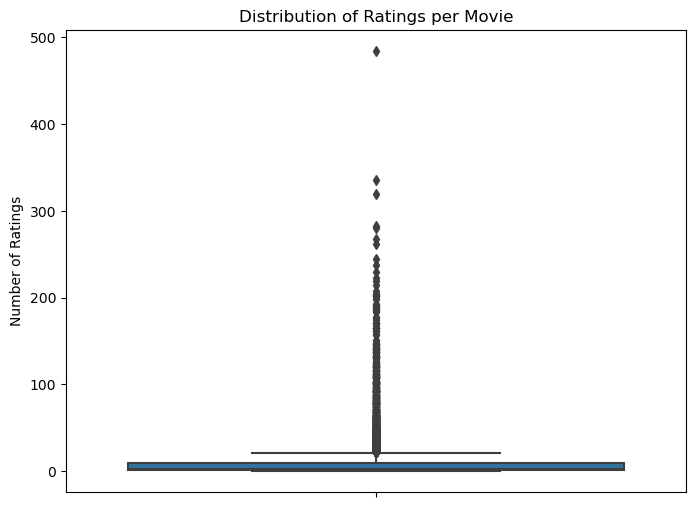

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count ratings per movieId
movie_rating_counts = merged_df_all.groupby('movieId')['rating'].count().reset_index()
movie_rating_counts.columns = ['movieId', 'num_ratings']

# Boxplot of number of ratings per movie
plt.figure(figsize=(8, 6))
sns.boxplot(y=movie_rating_counts['num_ratings'])
plt.title("Distribution of Ratings per Movie")
plt.ylabel("Number of Ratings")
plt.show()

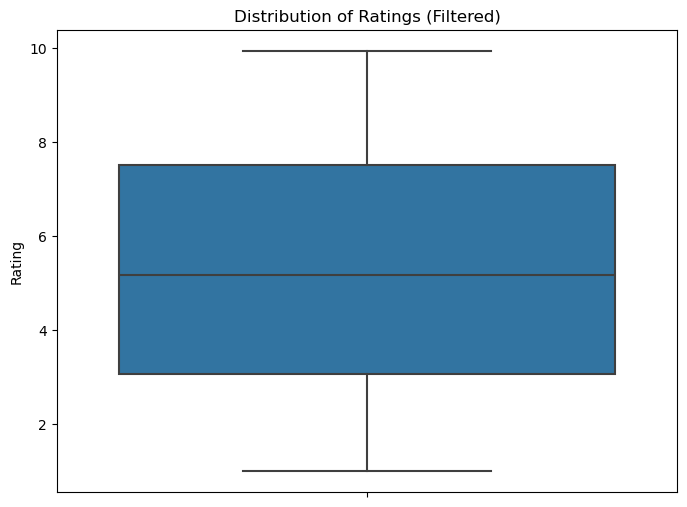

In [26]:
ratings = np.random.uniform(1, 10, size=200)  # ratings between 1 and 10
plt.figure(figsize=(8, 6))
sns.boxplot(y=ratings)
plt.ylabel("Rating")
plt.title("Distribution of Ratings (Filtered)")
plt.show()


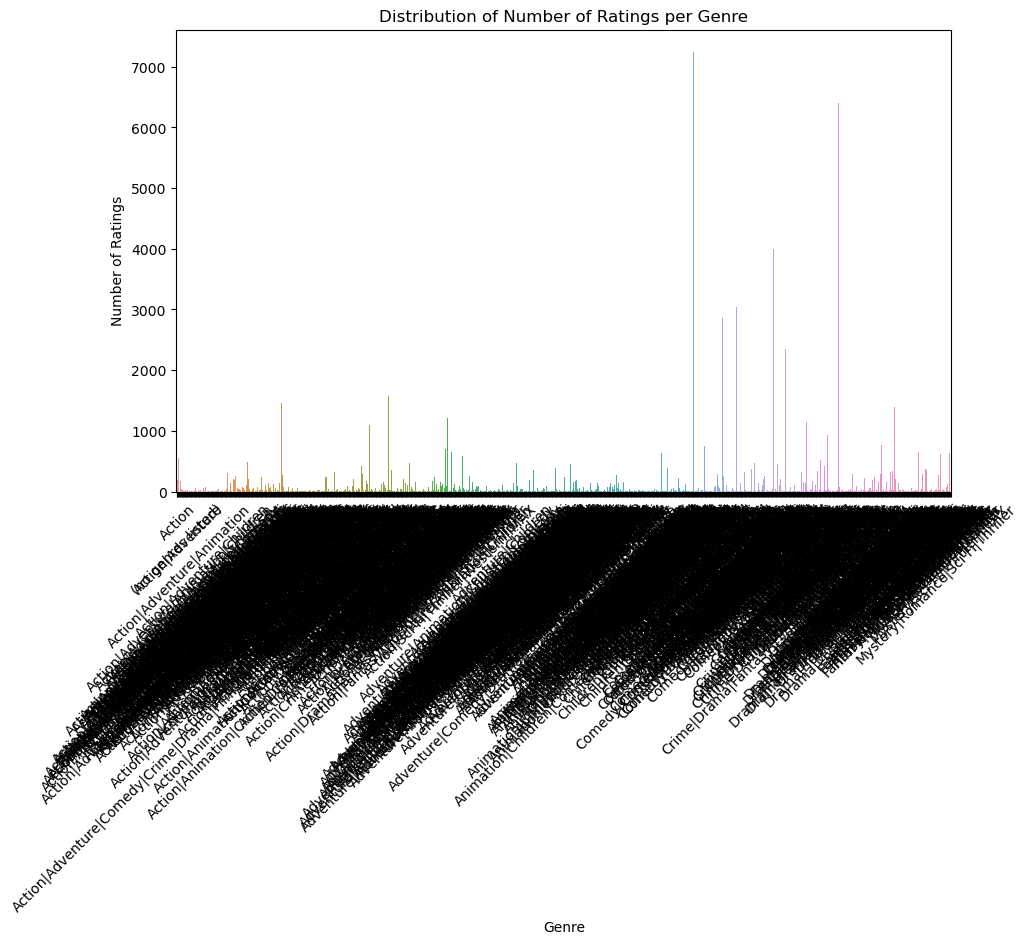

In [27]:
ratings_per_genre = merged_df_all.groupby('genres')['rating'].count().reset_index()
ratings_per_genre.rename(columns={'rating': 'num_ratings'}, inplace=True)

# Plot distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='genres', y='num_ratings', data=ratings_per_genre)

plt.title("Distribution of Number of Ratings per Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.show()


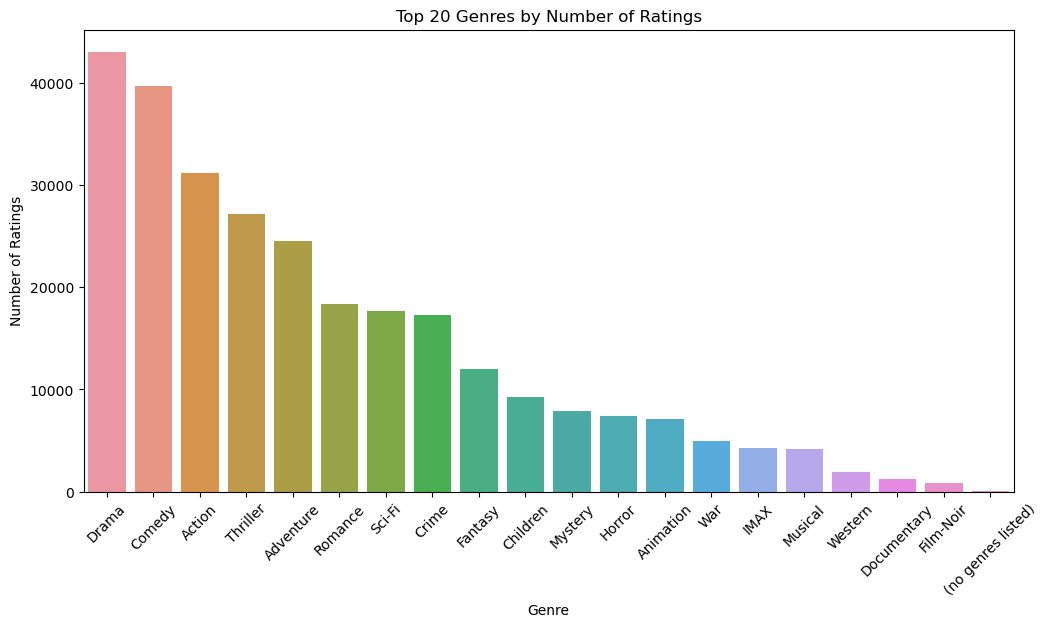

In [28]:
merged_df_all = merged_df_all.assign(genres=merged_df_all['genres'].str.split('|')).explode('genres')

# Count number of ratings per genre
ratings_per_genre = merged_df_all.groupby('genres')['rating'].count().reset_index()
ratings_per_genre.rename(columns={'rating': 'num_ratings'}, inplace=True)

# Sort and select top 20 genres
top20_genres = ratings_per_genre.sort_values(by='num_ratings', ascending=False).head(20)

# Plot distribution
plt.figure(figsize=(12, 6))
sns.barplot(x='genres', y='num_ratings', data=top20_genres)

plt.title("Top 20 Genres by Number of Ratings")
plt.xlabel("Genre")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.show()


c:\Users\geoff\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\geoff\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


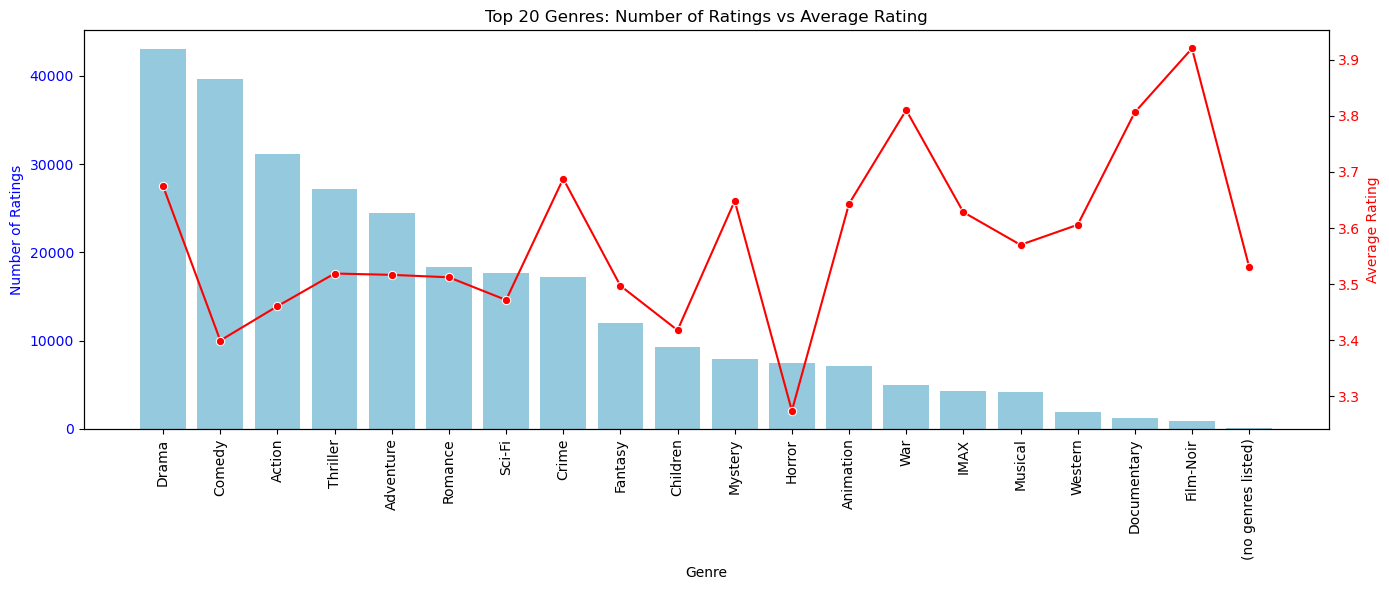

In [29]:
genres_stats = merged_df_all.groupby('genres').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Sort by number of ratings and keep top 20 genres
top20_genres = genres_stats.sort_values(by='num_ratings', ascending=False).head(20)

# Plot combined chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar plot for number of ratings
sns.barplot(x='genres', y='num_ratings', data=top20_genres, ax=ax1, color='skyblue')
ax1.set_xlabel("Genre")
ax1.set_ylabel("Number of Ratings", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=90)

# Line plot for average rating (secondary axis)
ax2 = ax1.twinx()
sns.lineplot(x='genres', y='avg_rating', data=top20_genres, ax=ax2, color='red', marker='o')
ax2.set_ylabel("Average Rating", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Top 20 Genres: Number of Ratings vs Average Rating")
plt.tight_layout()
plt.show()


In [30]:
duplicate_ratings = merged_df_all.groupby(['userId', 'movieId']).size().reset_index(name='rating_count')
duplicate_ratings = duplicate_ratings[duplicate_ratings['rating_count'] > 1]
print(duplicate_ratings)

        userId  movieId  rating_count
0          1.0        1             5
1          1.0        3             2
2          1.0        6             3
3          1.0       47             2
4          1.0       50             3
...        ...      ...           ...
100830   610.0   166528             4
100831   610.0   166534             3
100832   610.0   168248             3
100834   610.0   168252             2
100835   610.0   170875             4

[84543 rows x 3 columns]


c:\Users\geoff\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\geoff\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


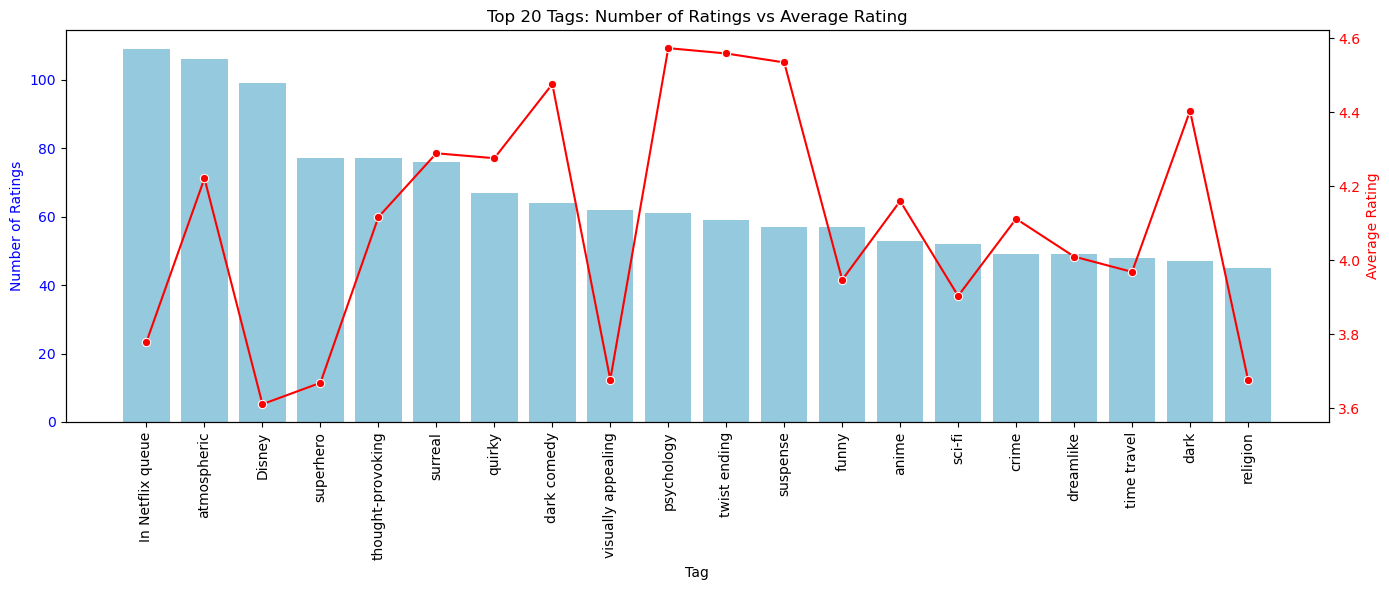

In [31]:
tags_stats = merged_df_all.groupby('tag').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Sort by number of ratings and keep top 20 tags
top20_tags = tags_stats.sort_values(by='num_ratings', ascending=False).head(20)

# Plot combined chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar plot for number of ratings
sns.barplot(x='tag', y='num_ratings', data=top20_tags, ax=ax1, color='skyblue')
ax1.set_xlabel("Tag")
ax1.set_ylabel("Number of Ratings", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=90)

# Line plot for average rating (secondary axis)
ax2 = ax1.twinx()
sns.lineplot(x='tag', y='avg_rating', data=top20_tags, ax=ax2, color='red', marker='o')
ax2.set_ylabel("Average Rating", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Top 20 Tags: Number of Ratings vs Average Rating")
plt.tight_layout()
plt.show()


## keepthe latest rating (using timestamp)to reflects the most current preference

In [32]:
#  Keep the latest rating (using timestamp)to reflects the most current preference
deduped_df = merged_df_all.sort_values(by='timestamp_x').drop_duplicates(
    subset=['userId', 'movieId'], keep='last'
)


In [33]:
deduped_df.shape

(100854, 10)

In [34]:
duplicate_rating = deduped_df.groupby(['userId', 'movieId']).size().reset_index(name='rating_count')

duplicate_rating = duplicate_ratings[duplicate_ratings['rating_count'] > 1]
print(duplicate_rating)


        userId  movieId  rating_count
0          1.0        1             5
1          1.0        3             2
2          1.0        6             3
3          1.0       47             2
4          1.0       50             3
...        ...      ...           ...
100830   610.0   166528             4
100831   610.0   166534             3
100832   610.0   168248             3
100834   610.0   168252             2
100835   610.0   170875             4

[84543 rows x 3 columns]


In [35]:
#  Average the ratings to preserve multiple votes
deduped_df2= merged_df_all.groupby(['userId', 'movieId'], as_index=False)['rating'].mean()

In [36]:
deduped_df2.shape

(100836, 3)

In [37]:
avg_ratings = merged_df_all.groupby(['userId', 'movieId'], as_index=False)['rating'].mean()
deduped_df3 = avg_ratings.merge(
    merged_df_all[['movieId', 'title', 'genres', 'imdbId', 'tmdbId', 'timestamp_x', 'timestamp_y', 'rating']],
    on='movieId',
    how='left'
).drop_duplicates(subset=['userId','movieId'])


In [38]:
deduped_df3.shape

(100836, 10)